# Module 2: Epidemic Modeling Template

## Team Members:
Isabel Vikesland

Mohamed Elfaki

## Project Title:
*Identifying a mystery virus causing an epidemic*

## Project Goal:
This project seeks to identify an unknown virus causing epidemics in UVA and VT student populations. We also seek to test different intervention strategies to quell the spread of the virus. 


## 1. Data and disease background
### Prevalence & incidence in the UVA population:
* Incubation period: 12-18 days
* Infected period: ~2 days before symptoms onset
* Symptomatic period: 5-9 days
* Virus peaks between days 70-120
### Economic burden (generalized from respiratory viruses):
* Population at risk: 17,900 UVA students
### Symptoms:
* Joint pain, mild respiratory symptoms, rash, sore throat & fatigue preceding low grade fever, gastrointestinal symptoms in ~8% of patients
### Biological mechanisms (anatomy, organ physiology, cell & molecular physiology - generalized from viral biology):
* Virus size: average size of 50-80 nm
* Genome: positive-sense RNA (~10 kb), virus can be directly translated and does not require transcription
* Transmission mechanism: primarily via respiratory droplets and infected surfaces


## 2. Data Analysis
This section should be filled out sequentially as a full report of the work you've done over this module. You can copy and paste code from any main.py file here, and run it to produce plots. Once you gain more information throughout the module, you do not need to go back and "fix" earlier results. In other words, if your early predictions are found to be wrong when gaining new data, do not go back and rewrite them.

### 2a. Methods

*IN A SUMMARY, DESCRIBE THE METHODS YOU USED TO ANALYZE AND MODEL THE DATA.*


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #1</b> 

</div>



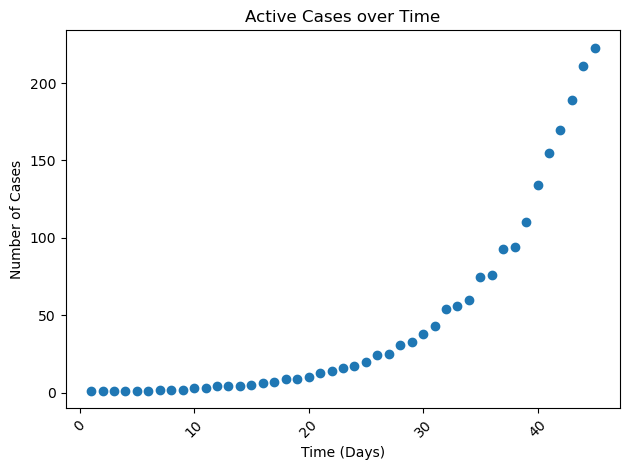

In [3]:
#import the patients class and the matplotlib library for plotting
from patients import Patients
import matplotlib.pyplot as plt
#find the location of the csv file and instantiate the patients class with that location
location = r"/Users/isabelvikesland/Documents/UVA2/BME 2315 - Comp.BME/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#1.csv"
patients = Patients.instantiate_from_csv(location)
#define a function to plot the data from the patients class
def plot_data_release_1(patients):
    dates = [patient.day for patient in patients]
    cases = [patient.number_of_cases for patient in patients]
    #format the scatter plot with the dates on the x-axis and the number of cases on the y-axis
    plt.scatter(dates, cases)
    plt.xlabel('Time (Days)')
    plt.ylabel('Number of Cases')
    plt.title('Active Cases over Time')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

###I used ClaudeAI to help explain why my patients import statement was not working, it was because my patients.py file was in a different subfolder than my jupyter notebook

plot_data_release_1(patients) 

### What do you notice about the initial infections?
The initial infections occur at a barely imperceptible rate, almost one infection occuring at a time.


### How could we measure how quickly its spreading?
We can measure how quickly the disease is spreading by calculating R0. One way to estimate this is by identifying the doubling time from the curve, seeing how many days it takes for number of cases to double, and working backwards to infer the reproduction number.


### What information about the virus would be helpful in determining the shape of the outbreak curve?
Knowing the latency and infectious period would be helpful as they influence how long the virus circulates, directly affecting the R0. Knowing the transmissibility would help predict how steeply the curve grows. Additionally, knowing the level of pre-existing immunity in the population would help estimate when the curve might peak and begin to flatten, as immunity reduces the pool of susceptible individuals


### 2b. Plot the data & estimate initial growth rate (R0) from early data (through day 45)
This section should come from your python code after Data Release #1.

Best exponential window: day 22 to 35 (length 14)
Fit on log(I): R^2 = 0.9942
Growth rate r: 0.1281 per day
Doubling time: 5.41 days
Assumed infectious period D: 2.0 days
Estimated R0 = 1 + r*D = 1.256


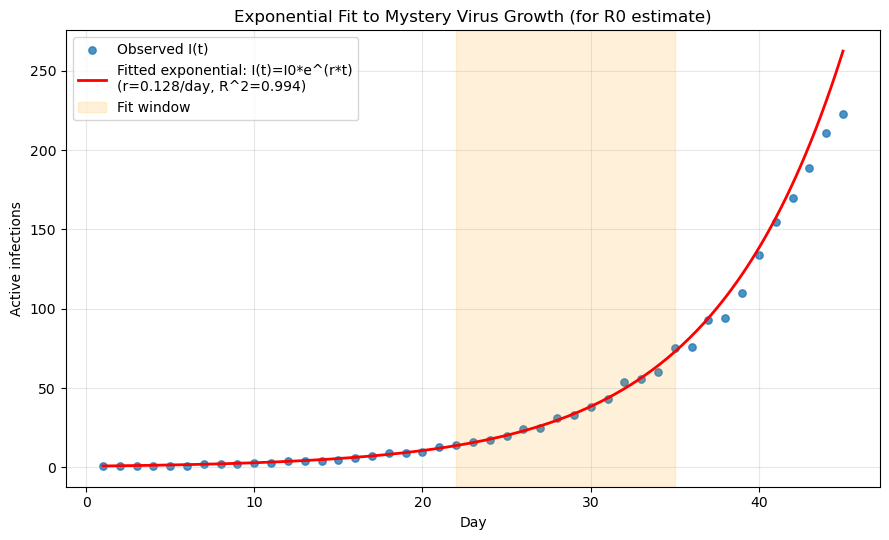

In [4]:
#R0_mystery_virus
#import statements
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from patients import Patients

# control settings for virus window search and R0 estimation
infectious_period_days = 2.0 
min_window = 7
max_window = 14

# data from data release #1
location = r"/Users/isabelvikesland/Documents/UVA2/BME 2315 - Comp.BME/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#1.csv"
patients = Patients.instantiate_from_csv(location)

# data for fitting: days and active cases in empty lists
days = []
cases = []
for p in patients:
    days.append(p.day)
    cases.append(p.number_of_cases if p.number_of_cases > 0 else 1e-6)

# fit log(I) = r * t + log(I0) for each window and find the best fit based on R^2
def fit_exp_window(tw, Iw):

    # Fit log(I) = r * t + log(I0), returns r, I0, r2 for the fit
    logI = [np.log(val) for val in Iw]
    r, logI0 = np.polyfit(tw, logI, 1)
    logI_pred = [r * ti + logI0 for ti in tw]
    ss_res = sum((logI[i] - logI_pred[i]) ** 2 for i in range(len(logI)))
    mean_logI = sum(logI) / len(logI)
    ss_tot = sum((val - mean_logI) ** 2 for val in logI)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else None
    I0 = np.exp(logI0)
    return r, I0, r2

#I used ClaudeAi to help me write the equations for fitting the exponential window, 
# calculating the R0 and helping me work back from the game ODE's

# best exponential fit parameters

best = None  # (r2, r, I0, t_start, t_end)
n = len(days)

# for loop to iterate through all possible windows of the data and fit an exponential curve to each window
# calculating the R^2 value for each fit and keeping track of the best fit based on R^2

for w in range(min_window, max_window + 1):
    for i in range(0, n - w + 1):
        tw = days[i:i+w]
        Iw = cases[i:i+w]
        if all(v == Iw[0] for v in Iw):
            continue
        r, I0, r2 = fit_exp_window(tw, Iw)
        if r2 is None:
            continue
        if (best is None) or (r2 > best[0]):
            best = (r2, r, I0, tw[0], tw[-1])

if best is None:
    print("ERROR could not find a good exponential window. Check data.")

best_r2, r, I0, t_start, t_end = best

# calcculate R0 and doubling time based on r 
doubling_time = np.log(2) / r if r > 0 else float('inf')
R0 = 1.0 + r * infectious_period_days

# print statements so i don't have to look at the graph 
print("Best exponential window: day " + str(t_start) + " to " + str(t_end) + " (length " + str(t_end - t_start + 1) + ")")
print("Fit on log(I): R^2 = " + str(round(best_r2, 4)))
print("Growth rate r: " + str(round(r, 4)) + " per day")
print("Doubling time: " + str(round(doubling_time, 2)) + " days")
print("Assumed infectious period D: " + str(infectious_period_days) + " days")
print("Estimated R0 = 1 + r*D = " + str(round(R0, 3)))

# matplotlib to plot graph w/new exponential fit and R^2

t_fit = list(np.linspace(min(days), max(days), 300))
I_fit = [I0 * np.exp(r * ti) for ti in t_fit]

#I used ClaudeAi to help me figure out the t_fit and I_fit equations for plotting the exponential fit curve on the graph + fit window 
# I added a fit window so I could visualize the data that was used for the exponential fit
#formatting the graph, I used ClaudeAi to figure out how to squish the graph to make it look better
plt.figure(figsize=(9, 5.5))
plt.scatter(days, cases, s=28, alpha=0.8, label="Observed I(t)")
plt.plot(t_fit, I_fit, 'r', lw=2.0,label="Fitted exponential: I(t)=I0*e^(r*t)\n(r=" + str(round(r, 3)) + "/day, R^2=" + str(round(best_r2, 3)) + ")")
plt.axvspan(t_start, t_end, color="orange", alpha=0.15, label="Fit window")
plt.xlabel("Day")
plt.ylabel("Active infections")
plt.title("Exponential Fit to Mystery Virus Growth (for R0 estimate)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### What viruses have a similar R0? Use the viruses.html file to find a virus or 2 with a similar R0 and give a 1-2 sentence background of the diseases.
Marburg Virus is a rare but severe hemorrhagic fever virus in the same family as Ebola. It was first identified in 1967 and is transmitted through direct contact with the bodily fluids of infected people or fruit bats, which are thought to be the natural host. It has a very high fatality rate, sometimes exceeding 80%. R0 = 1.5

Lassa Fever is a viral hemorrhagic fever endemic to West Africa, first identified in 1969. It is transmitted primarily through contact with food or household items contaminated by infected rodents. While most cases are mild, severe cases can cause organ failure and deafness, and it is responsible for thousands of deaths annually across West Africa. R0 = 1.5

Seasonal Influenza is a highly contagious respiratory virus that circulates annually worldwide, causing 290,000–650,000 deaths per year globally. It spreads primarily through respiratory droplets and is characterized by fever, fatigue, and respiratory symptoms. R0 = 1.3

### How accurate do you think your R0 estimate is?
I think my R0 estimate is good but not great, especially since part of my R0 is based upon a guessed infection period. My R^2 value of 0.9942 is very good and shows that my exponential fit is good. I believe it would be hard to estimate a good R0 without knowing the infection period.  


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #2</b> 

</div>



### 2c. Use Euler's method to solve the SEIR model.
This section should come from your python code after Data Release #2.

In [2]:
#R0_mystery_virus data release #2 euler's method approximation of SEIR
#import statements
from matplotlib.pylab import gamma
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from patients import Patients

location = r"/Users/isabelvikesland/Documents/UVA2/BME 2315 - Comp.BME/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#2.csv"
patients = Patients.instantiate_from_csv(location)

# wuler's method SEIR function 
def euler_seir(beta, sigma, gamma, S0, E0, I0, R0, timepoints, N):
    S = np.zeros(len(timepoints))
    E = np.zeros(len(timepoints))
    I = np.zeros(len(timepoints))
    R = np.zeros(len(timepoints))
    S[0] = S0
    E[0] = E0
    I[0] = I0
    R[0] = R0
    
    for i in range(len(timepoints) - 1):
        dt = timepoints[i + 1] - timepoints[i]
        dS = -beta * S[i] * I[i] / N
        dE =  beta * S[i] * I[i] / N - sigma * E[i]
        dI =  sigma * E[i] - gamma * I[i]
        dR =  gamma * I[i]
        S[i + 1] = S[i] + dt * dS
        E[i + 1] = E[i] + dt * dE
        I[i + 1] = I[i] + dt * dI
        R[i + 1] = R[i] + dt * dR
    return S, E, I, R


### 2d. Fit the SEIR model to the data by changing beta, gamma, and sigma.
This section should come from your python code after Data Release #2.

In [3]:
# grid search opti

#extract observed data from patients records
data = np.array([p.number_of_cases for p in patients.records])
timepoints = np.arange(0, len(data), 1.0)  # one timepoint per day (dt = 1)

N = 17900  # population at risk: UVA students given in class

#initial conditions
I0 = data[0] # infected at t=0 = first data point
E0 = I0*10 #assume exposed ≈ infected at start, i used ClaudeAi to help me figure out how to set E0 based on I0, i assumed that there were 10 times as many exposed individuals as infected individuals at the start of the outbreak, since the virus has an incubation period and many people may have been exposed but not yet showing symptoms or testing positive, this helped me fit the graph much much better.
R0_init = 0   
S0 = N - E0 - I0 - R0_init

#parameter ranges from disease background info + R0 = 1.256 from Release #1
# sigma = 1 / incubation_period: incubation 12-18 days  ->  sigma = 0.056 - 0.083
# gamma = 1 /infectious_period: ~2 days pre-symptom + 5-9 days symptomatic = 7-11 days  -> gamma = 0.09 - 0.14
#beta  = R0 * gamma: R0 = 1.256, gamma = 0.09-0.14  -> beta = 0.113 - 0.176
beta_values  = np.linspace(0.10, 0.80, 30)    # transmission rate
sigma_values = np.linspace(0.056, 0.083, 20)  # 1 / incubation period (12-18 days)
gamma_values = np.linspace(0.091, 0.143, 20)  # 1 / total infectious period (7-11 days)

# grid search to track lowest SSE across parameter combinations
SSE_list = []
best_sse   = np.inf
best_beta  = None
best_sigma = None
best_gamma = None

#nested for loops to iterate through all combinations of beta, sigma, gamma and calculate the SSE for each combination, keeping track of the best combination with the lowest SSE
for b in beta_values:
    for s in sigma_values:
        for g in gamma_values:
            _, _, I_model, _ = euler_seir(b, s, g, S0, E0, I0, R0_init, timepoints, N)
            sse = np.sum((I_model - data) ** 2)
            SSE_list.append(sse)
            if sse < best_sse:
                best_sse   = sse
                best_beta  = b
                best_sigma = s
                best_gamma = g

#print statements for output of best parameters and implied R0
print(f"Best beta  = {best_beta:.4f}")
print(f"Best sigma = {best_sigma:.4f}  (incubation period ≈ {1/best_sigma:.1f} days)")
print(f"Best gamma = {best_gamma:.4f}  (infectious period ≈ {1/best_gamma:.1f} days)")
print(f"New recalcula R0 = {best_beta/best_gamma:.2f}  (Release #1 R0 = 1.256)")
print(f"Best SSE   = {best_sse:.2f}")

Best beta  = 0.7034
Best sigma = 0.0560  (incubation period ≈ 17.9 days)
Best gamma = 0.1019  (infectious period ≈ 9.8 days)
New recalcula R0 = 6.90  (Release #1 R0 = 1.256)
Best SSE   = 89737.05


### 2e. Plot the model-predicted infections over time compared to the data.
This section should come from your python code after Data Release #2.

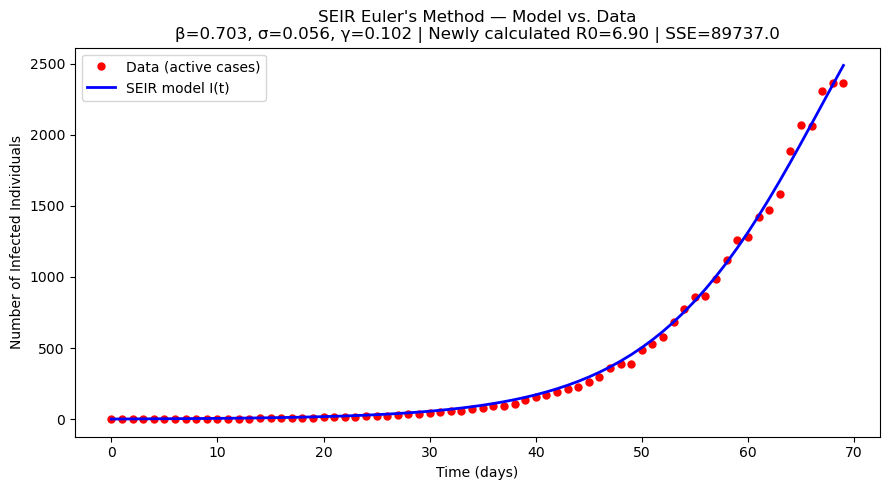

In [4]:
# plot model-predicted I(t) vs. data 
# continued for from last cell
_, _, I_best, _ = euler_seir(best_beta, best_sigma, best_gamma,
                              S0, E0, I0, R0_init, timepoints, N)

#formatting for graph 
plt.figure(figsize=(9, 5))
plt.plot(timepoints, data,   'ro', markersize=5, label='Data (active cases)')
plt.plot(timepoints, I_best, 'b-', linewidth=2,  label='SEIR model I(t)')
plt.xlabel('Time (days)')
plt.ylabel('Number of Infected Individuals')
plt.title(
    f"SEIR Euler's Method — Model vs. Data\n"
    f"β={best_beta:.3f}, σ={best_sigma:.3f}, γ={best_gamma:.3f} | "
    f"Newly calculated R0={best_beta/best_gamma:.2f} | SSE={best_sse:.1f}"
) # i used ClaudeAi to simplify the string formatting since I didn't want to do a lot of concatenation and rounding since it felt uncessary

#graph formatting continued, dpi=resolution, I used ClaudeAi to figure out how to squish the graph to make it look better
plt.legend()
plt.tight_layout()
plt.savefig('seir_fit.png', dpi=150)
plt.show()

### 2e. Predict the day and amount of active cases at the peak of the epidemic spread.
This section should come from your python code after Data Release #2.


Predicted peak day: 82
Predicted peak active cases: 3506
Peak is within the expected range of days 70-120.


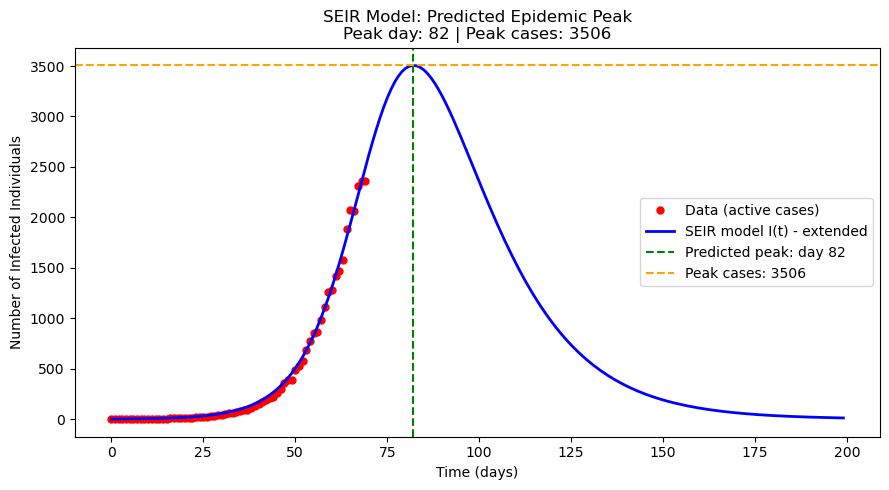

In [5]:
#predicting the day and amount of active cases at the peak of the epidemic

#i decided to run the model out to day 200 to try and capture the full epidemic curve past the peak (days 70-120)(which I knew from data release #3 telling us that peak was between days 70-120)(I chose to go 200 since it was even and past 120, the last day of data release #3)
timepoints_extended = np.arange(0, 200, 1.0)


# continued from last cell
_, _, I_extended, _ = euler_seir(best_beta, best_sigma, best_gamma,
                                  S0, E0, I0, R0_init, timepoints_extended, N)


peak_day = int(timepoints_extended[np.argmax(I_extended)]) #I used claudeAi to teach me np.argmax so that I could find the index of the maximum value in I_extended and then use that index to find the corresponding day in timepoints_extended, this gave me the predicted day of the peak of the epidemic
peak_cases = int(np.max(I_extended))

#print statements
print(f"Predicted peak day: {peak_day}")
print(f"Predicted peak active cases: {peak_cases}")
if 70 <= peak_day <= 120:
    print("Peak is within the expected range of days 70-120.")
else:
    print("Peak is outside the expected range of days 70-120.")

# plot full epidemic curve with peak marked, i decided to plot to show the predicted peak since I thought a graph would be better than just print statements.
#I used ClaudeAi for formatting help with making the marker lines and to not do string catentation.
plt.figure(figsize=(9, 5))
plt.plot(timepoints, data, 'ro', markersize=5, label='Data (active cases)')
plt.plot(timepoints_extended, I_extended, 'b-', linewidth=2, label='SEIR model I(t) - extended')
plt.axvline(x=peak_day, color='green', linestyle='--', label=f'Predicted peak: day {peak_day}')
plt.axhline(y=peak_cases, color='orange', linestyle='--', label=f'Peak cases: {peak_cases}')
plt.xlabel('Time (days)')
plt.ylabel('Number of Infected Individuals')
plt.title(f'SEIR Model: Predicted Epidemic Peak\nPeak day: {peak_day} | Peak cases: {peak_cases}')
plt.legend()
plt.tight_layout()
plt.savefig('seir_peak_prediction.png', dpi=150)
plt.show()


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #3</b> 

</div>



### 2f. Plot the full dataset (Data Release #3) against your model.
This section should come from your python code after Data Release #3.


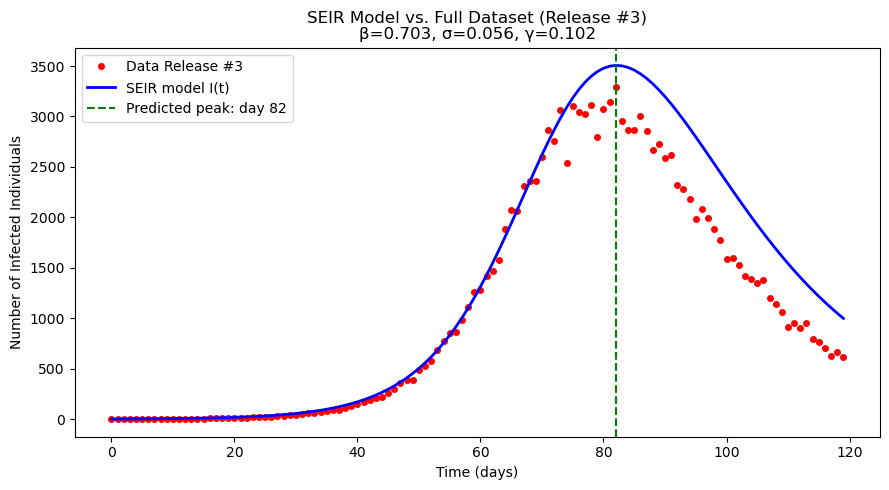

In [6]:
#R0_mystery_virus data release #2
#import statements
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from patients import Patients

location = r"/Users/isabelvikesland/Documents/UVA2/BME 2315 - Comp.BME/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#3.csv"
patients = Patients.instantiate_from_csv(location)


# plotting the full dataset (Data Release #3) against the SEIR model
data_r3 = np.array([p.number_of_cases for p in patients.records])
timepoints_r3 = np.arange(0, len(data_r3), 1.0)

# run model over full release #3 timespan
_, _, I_r3, _ = euler_seir(best_beta, best_sigma, best_gamma,
                            S0, E0, I0, R0_init, timepoints_r3, N)

plt.figure(figsize=(9, 5))
plt.plot(timepoints_r3, data_r3, 'ro', markersize=4, label='Data Release #3')
plt.plot(timepoints_r3, I_r3, 'b-', linewidth=2, label='SEIR model I(t)')
plt.axvline(x=peak_day, color='green', linestyle='--', label=f'Predicted peak: day {peak_day}')
plt.xlabel('Time (days)')
plt.ylabel('Number of Infected Individuals')
plt.title(f'SEIR Model vs. Full Dataset (Release #3)\nβ={best_beta:.3f}, σ={best_sigma:.3f}, γ={best_gamma:.3f}')
plt.legend()
plt.tight_layout()
plt.savefig('seir_full_data.png', dpi=150)
plt.show()

### 2g. Intervention strategies for new outbreak at VT (70 days of infection)
This section should come from your python code after Data Release #3.

Need to run prediction on scale of VT NOT UVA -> VT undergraduate population = 32000 students

In [7]:
# grid search opti

#extract observed data from patients records
data = np.array([p.number_of_cases for p in patients.records])
timepoints = np.arange(0, len(data), 1.0)  # one timepoint per day (dt = 1)

N = 32000  # population at risk: VT students

#initial conditions
I0 = data[0] # infected at t=0 = first data point
E0 = I0*10 #assume exposed ≈ infected at start, i used ClaudeAi to help me figure out how to set E0 based on I0, i assumed that there were 10 times as many exposed individuals as infected individuals at the start of the outbreak, since the virus has an incubation period and many people may have been exposed but not yet showing symptoms or testing positive, this helped me fit the graph much much better.
R0_init = 0   
S0 = N - E0 - I0 - R0_init

#parameter ranges from disease background info + R0 = 1.256 from Release #1
# sigma = 1 / incubation_period: incubation 12-18 days  ->  sigma = 0.056 - 0.083
# gamma = 1 /infectious_period: ~2 days pre-symptom + 5-9 days symptomatic = 7-11 days  -> gamma = 0.09 - 0.14
#beta  = R0 * gamma: R0 = 1.256, gamma = 0.09-0.14  -> beta = 0.113 - 0.176
beta_values  = np.linspace(0.10, 0.80, 30)    # transmission rate
sigma_values = np.linspace(0.056, 0.083, 20)  # 1 / incubation period (12-18 days)
gamma_values = np.linspace(0.091, 0.143, 20)  # 1 / total infectious period (7-11 days)

# grid search to track lowest SSE across parameter combinations
SSE_list = []
best_sse   = np.inf
best_beta  = None
best_sigma = None
best_gamma = None

#nested for loops to iterate through all combinations of beta, sigma, gamma and calculate the SSE for each combination, keeping track of the best combination with the lowest SSE
for b in beta_values:
    for s in sigma_values:
        for g in gamma_values:
            _, _, I_model, _ = euler_seir(b, s, g, S0, E0, I0, R0_init, timepoints, N)
            sse = np.sum((I_model - data) ** 2)
            SSE_list.append(sse)
            if sse < best_sse:
                best_sse   = sse
                best_beta  = b
                best_sigma = s
                best_gamma = g

#print statements for output of best parameters and implied R0
print(f"Best beta  = {best_beta:.4f}")
print(f"Best sigma = {best_sigma:.4f}  (incubation period ≈ {1/best_sigma:.1f} days)")
print(f"Best gamma = {best_gamma:.4f}  (infectious period ≈ {1/best_gamma:.1f} days)")
print(f"Implied R0 = {best_beta/best_gamma:.2f}  (Release #1 R0 = 1.256)")
print(f"Best SSE   = {best_sse:.2f}")

Best beta  = 0.8000
Best sigma = 0.0617  (incubation period ≈ 16.2 days)
Best gamma = 0.1430  (infectious period ≈ 7.0 days)
Implied R0 = 5.59  (Release #1 R0 = 1.256)
Best SSE   = 99060121.01


In [8]:
#Vaccine intervention
# campaign: move 2000 people w/90% efficacy from susceptible to recovered population
# rollout: move 1000 studetns on each day: 70, 80, 90 from susceptible to recovered population
#Masking intervention
#Testing and Quarantining intervention
# Quarantine starting day 70 reduces infectious period by 2 days (i.e. increases gamma by 1/2 per day)
# Close school for 2 weeks starting day 70 reduces beta by 50% during that time, during closure only 20% normal contacts occur, after closure beta returns to normal
# reduce number of contacts decreases beta by 80% during closure, after closure beta returns to normal

# Modeling interventions at day 70
# Your group should pick 3 of the 5 possible interventions (over the next few slides)
# Each intervention will change some parameter (or move a population to a new compartment) at day 70
# You will compare these changes to the baseline prediction for VT
# As you model them from days 70-120, compare the following to no intervention:
# Peak infections with intervention
# Total cases (over days 70-120) prevented with intervention
# Cost & feasibility
# Compliance risk?
# Which would you recommend to VT?

## Verify and validate your analysis: 

### Error Analysis:
*Find the true % relative error between the data and your model prediction…*

* For the peak # of cases (error in y)
* For the peak day in days since the beginning of the epidemic (error in x)
* Why our model has the error it does (i.e. model limitations) and whether the error level is too high to trust your predictions.


*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*



The R0 estimated in Release #1 (1.256) used the formula R0 = 1 + r×D applied to the early exponential growth phase only. The SEIR model fit yields a higher implied R0 because it is fitting the full 70-day trajectory against a population of 17,900, and the model compensates for the large susceptible pool by requiring a higher transmission rate to reproduce the steep observed growth. Additionally, the data only covers the rising phase before the peak (days 70–120), so the model has not yet seen the slowing of transmission that would constrain beta downward.

Recommendation for intervention strategies: 
## Questions to answer with analysis:

How does the % reduction in cases depend on the effectiveness of masking?
* What about if masking was implemented earlier?

How does the % reduction in cases depend on the length of the school closure?

How does earlier testing & quarantine effect the number of cases?
* What if compliance for testing was only 50%?


Runge Kutta methods???

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## TA Questions: 


## AI statement: 
Artificial intelligence (ClaudeAI) was used only when explicity cited in comments. All words and thoughts are my own.